In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

In [5]:
shell = r'C:\Users\187697\Dropbox\sa_fires\proj_bureaucrats_farms'
dbox = fr'C:\Users\eunic\Dropbox\sa_fires'
main = dbox
inter_path = f'{main}/proj_bureaucrats_farms/data_output/intermediate'
figures = f"{main}/proj_bureaucrats_farms/tex/paper/figures"


In [6]:
protests = pd.read_csv(fr'{main}/data/input/acled/2000-01-01-2025-05-13-South_Asia-India.csv', sep = ';')
protests['event_date'] = pd.to_datetime(protests['event_date'], dayfirst=True)

# Define date range
start_date = pd.to_datetime('2020-06-01')
end_date = pd.to_datetime('2021-12-09')
filtered_protests = protests[(protests['event_date'] >= start_date) & 
                             (protests['event_date'] <= end_date)].copy()

C:\Users\eunic\AppData\Local\Temp\ipykernel_34736\2835841809.py:1: DtypeWarning: Columns (0: civilian_targeting, 1: tags) have mixed types. Specify dtype option on import or set low_memory=False.
  protests = pd.read_csv(fr'{main}/data/input/acled/2000-01-01-2025-05-13-South_Asia-India.csv', sep = ';')


In [7]:
filtered_protests['assoc_actor_1'] = filtered_protests['assoc_actor_1'].str.lower()
mask = filtered_protests['assoc_actor_1'].str.lower().str.contains(r'\bfarm\w*', na=False)
mask2 = filtered_protests['notes'].str.lower().str.contains(r'\bfarm\w*', na=False)
filtered_protests_type = filtered_protests[mask | mask2].copy()


In [8]:
filtered_protests_not = filtered_protests[~(mask|mask2)].copy()
filtered_protests_not['year_month'] = filtered_protests_not['event_date'].dt.to_period('M')


In [9]:
# Create a 'year-month' column
filtered_protests_type['year_month'] = filtered_protests_type['event_date'].dt.to_period('M')



In [10]:
# Count observations per month
monthly_counts = filtered_protests_type[['year_month', 'admin1']].drop_duplicates()['year_month'] \
                             .value_counts().sort_index()

# Convert PeriodIndex to datetime for plotting
monthly_counts.index = monthly_counts.index.to_timestamp()


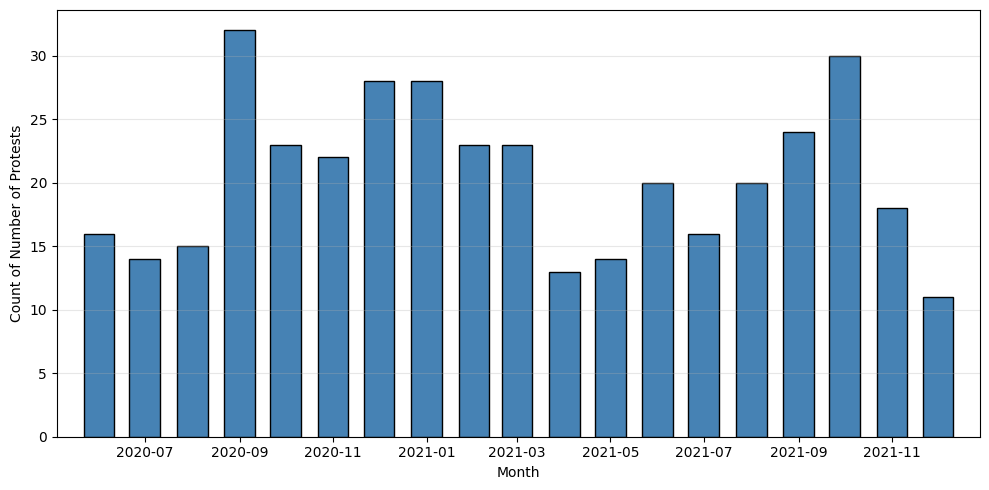

In [12]:
# Plot as bar chart
plt.figure(figsize=(10,5))
plt.bar(monthly_counts.index, monthly_counts.values, 
        color='steelblue', edgecolor='black', width=20)

# plt.title("Monthly Number of Distinct Protest Events")
plt.xlabel("Month")
plt.ylabel("Count of Number of Protests")
plt.grid(alpha=0.3, axis='y')

# Add a small margin on both sides (5% of total range)
x_min, x_max = monthly_counts.index.min(), monthly_counts.index.max()
x_range = x_max - x_min
plt.xlim(x_min - x_range * 0.05, x_max + x_range * 0.05 )

# Hide any tick labels that fall outside data range
plt.tick_params(axis='x', which='both', labelbottom=True)
plt.tight_layout()
# Save and show
plt.savefig(f"{figures}/protests_monthly_bars.png", dpi=300)
plt.show()

In [14]:
acs = gpd.read_file(fr'{inter_path}/_0_2_3_ACs_right_shapefile.shp')
acs['area_ac'] = acs.to_crs(7755).area

In [15]:
# Replace with actual column names if different
geometry = gpd.points_from_xy(filtered_protests_type.longitude, filtered_protests_type.latitude)

# Create GeoDataFrame with WGS84 CRS
protest_info = gpd.GeoDataFrame(filtered_protests_type, geometry=geometry, crs="EPSG:4326")

In [16]:
acs_pro = gpd.overlay(protest_info,acs, keep_geom_type=True)
acs_pro = acs_pro.reset_index(drop=True).reset_index().rename(columns={'index':'protest_id'})


In [17]:
npros_byac = acs_pro.groupby('ac_uq_id').size().reset_index().rename(columns = {0:'npros'})

In [18]:
ac_sel = 285
geom = acs_pro.query(f'ac_uq_id == {ac_sel}').copy()
# Project to meters
geom_proj = geom.to_crs(epsg=7755)

# Buffer in meters (dist_km assumed to be defined already)
geom_proj['geometry'] = geom_proj.geometry.buffer(5 * 1000)

# Reproject back to WGS84
geom_proj = geom_proj.to_crs(epsg=4326)
# geom_proj.plot()


In [19]:
geom_proj_aux = geom_proj.drop_duplicates(['latitude', 'longitude'])

In [20]:
acs.query(f'ac_uq_id == {ac_sel}')

,ac_uq_id,STATE_UT,DISTRICT,ASSEMBLY_1,ASSEMBLY,acpost08ID,geometry,area_ac
784,285,HARYANA,JIND,JIND,36.0,2714.0,"POLYGON ((76.43832 29.3486, 76.42685 29.34241,...",2.144403e+08


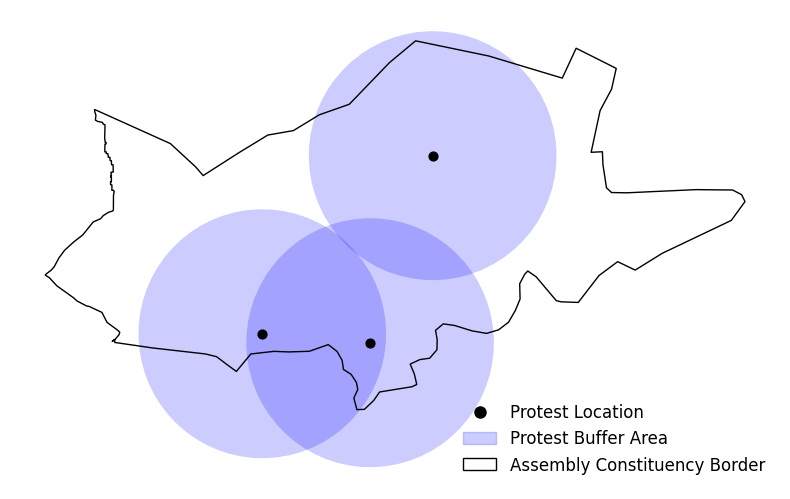

In [21]:
import geopandas as gpd
import matplotlib.pyplot as plt

# --- Plot setup ---
fig, ax = plt.subplots(figsize=(8, 8))

# 1. Plot protest buffer area (blue)
geom_proj_aux.plot(ax=ax, color='blue', linewidth=0.7, label='Protest Buffer Area', alpha = 0.2)

# 2. Plot protest location(s) at the center of the buffer (red point)
ax.scatter(geom_proj_aux['longitude'], geom_proj_aux['latitude'],
           color='black', marker='o', s=40, zorder=5, label='Protest Location')

# 3. Plot Assembly Constituency border (black)
acs.query(f'ac_uq_id == {ac_sel}').boundary.plot(ax=ax, color='black', linewidth=1.0, label='Assembly Constituency Border')

# 4. Legend & formatting
protest_point = plt.Line2D([], [], color='black', marker='o', linestyle='None', markersize=8, label='Protest Location')
protests_patch = mpatches.Patch(color='blue', alpha=0.2, label='Protest Buffer Area')
ac_patch = mpatches.Patch(edgecolor='black', facecolor='none', label='Assembly Constituency Border')
ax.legend(
    handles=[protest_point, protests_patch, ac_patch],
    loc='lower right',
    fontsize=12,
    frameon=False
)

ax.axis('off')

plt.tight_layout()
plt.savefig(f"{figures}/ac_protest_plot.png", dpi=300)

plt.show()

In [22]:
ac_list = acs_pro.ac_uq_id.unique().tolist()

In [23]:
from shapely.geometry import Polygon, MultiPolygon
import geopandas as gpd
import pandas as pd

# Example list of ac_uq_ids to loop through
buffer_results = []
dist_km = 5
for ac_val in ac_list:
    geom = acs_pro.query(f'ac_uq_id == {ac_val}').copy()
    if geom.empty:
        continue

    # Project to meters
    geom_proj = geom.to_crs(epsg=7755)

    # Buffer in meters (dist_km assumed to be defined already)
    geom_proj['geometry'] = geom_proj.geometry.buffer(dist_km * 1000)

    # Reproject back to WGS84
    geom_proj = geom_proj.to_crs(epsg=4326)

    # Intersect with acs
    intersected = gpd.overlay(acs, geom_proj, how='intersection')

    if intersected.empty:
        continue

    # Union all geometries to get single (multi)polygon
    unified = intersected.unary_union

    # Convert to GeoSeries for exploding
    if isinstance(unified, Polygon):
        gdf = gpd.GeoDataFrame(geometry=[unified], crs=acs.crs)
    elif isinstance(unified, MultiPolygon):
        gdf = gpd.GeoDataFrame(geometry=list(unified.geoms), crs=acs.crs)
    else:
        continue  # skip unexpected geometry

    # Optionally add identifier column
    gdf['ac_uq_id'] = ac_val

    # Append to list
    buffer_results.append(gdf)

# Combine all into a single GeoDataFrame
buffer_combined = pd.concat(buffer_results, ignore_index=True)

# Optional: reset geometry column if needed
buffer_combined = gpd.GeoDataFrame(buffer_combined, geometry='geometry', crs=acs.crs)


C:\Users\eunic\AppData\Local\Temp\ipykernel_34736\2416965235.py:29: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  unified = intersected.unary_union
C:\Users\eunic\AppData\Local\Temp\ipykernel_34736\2416965235.py:29: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  unified = intersected.unary_union
C:\Users\eunic\AppData\Local\Temp\ipykernel_34736\2416965235.py:29: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  unified = intersected.unary_union
C:\Users\eunic\AppData\Local\Temp\ipykernel_34736\2416965235.py:29: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  unified = intersected.unary_union
C:\Users\eunic\AppData\Local\Temp\ipykernel_34736\2416965235.py:29: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  unified =

In [24]:
buffer_combined = buffer_combined.reset_index().rename(columns={'index':'protest_place'})

### Intersection Buffer and time treatment

In [26]:
grids = gpd.read_file(fr"{dbox}/proj_downwind/data_output/intermediate/1-grid-generation.shp")
# Selecting the protests in the ACs
protest_info_buff = acs_pro.copy()
protest_info_buff['geometry'] = acs_pro.to_crs(7755).buffer(5000).to_crs(4326)
grids_protest = gpd.overlay( grids, protest_info_buff )
grids_protest['event_date'] = pd.to_datetime(grids_protest['event_date'])

# Get the rows with the minimum event_date per unq_s__
min_rows = grids_protest.loc[grids_protest.groupby('unq_s__')['event_date'].idxmin()]
grid_protest_id = min_rows[['unq_s__', 'protest_id', 'event_date']].copy()



In [27]:
protest_int = gpd.overlay( acs_pro, buffer_combined )
protest_int = protest_int.query('ac_uq_id_1 == ac_uq_id_2')
info = protest_int[[ 'protest_id', 'protest_place' ]]

In [28]:
print(protest_int.shape)
print(acs_pro.shape)
print(buffer_combined.shape)

(3033, 44)
(3033, 42)
(390, 3)


In [29]:
grids_buffer_protest_time = grid_protest_id.merge(info, on ='protest_id', how = 'left')

In [30]:
print(grids_buffer_protest_time.unq_s__.is_unique)
grids_buffer_protest_time.isna().sum()
print(grids_buffer_protest_time.shape)
grids_buffer_protest_time['yr_pr_5km'] = grids_buffer_protest_time.event_date.dt.year
grids_buffer_protest_time['mt_pr_5km'] = grids_buffer_protest_time.event_date.dt.month
grids_buffer_protest_time.drop('event_date', axis = 1) \
        .to_csv(fr'{inter_path}/8_grids_ac_pr_5km.csv', index = False)

True
(12902, 4)


In [34]:
grids_buffer_protest_time.columns

Index(['unq_s__', 'protest_id', 'event_date', 'protest_place', 'yr_pr_5km',
       'mt_pr_5km'],
      dtype='str')

In [ ]:
grids_buffer_protest_time['protest_place'].nunique()

388

: 